In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/master/kaggle-houseprice/data_combined_cleaned.csv")

In [4]:
df = df.dropna()

In [6]:
df = df.drop(columns="Id")
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalesPrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,Inside,Gtl,...,0,None,None,None,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,FR2,Gtl,...,0,None,None,None,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,Inside,Gtl,...,0,None,None,None,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,Corner,Gtl,...,0,None,None,None,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,FR2,Gtl,...,0,None,None,None,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,Inside,Gtl,...,0,None,None,None,0,8,2007,WD,Normal,175000.0
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,Inside,Gtl,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000.0
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,Inside,Gtl,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500.0
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,Inside,Gtl,...,0,None,None,None,0,4,2010,WD,Normal,142125.0


rmse train 0.12339045211372363
rmse test 0.12010968512432947
r2 train 0.9079911048299707
r2 test 0.900408745164719


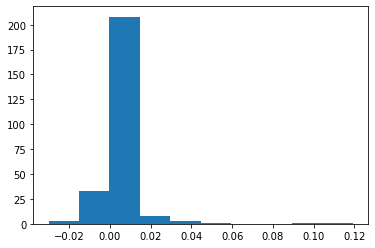

In [16]:
from sklearn import *


target = "SalesPrice"

y = np.log(df[target]) # label

X = df.drop(columns=target) # features


# Derives feature
#X["high_bmi"] = X.bmi>33
#X = pd.get_dummies(X, drop_first=True)
#X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.Lasso(alpha=0.005, max_iter=10000))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
est.intercept_, est.coef_
plt.hist(est.coef_);

In [ ]:
from sklearn import *


target = "SalesPrice"

y = np.log(df[target]) # label

X = df.drop(columns=target) # features


# Derives feature
#X["high_bmi"] = X.bmi>33
#X = pd.get_dummies(X, drop_first=True)
#X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.Ridge(alpha=1.0, max_iter=10000))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
est.intercept_, est.coef_
plt.hist(est.coef_);

rmse train 0.12352165919175516
rmse test 0.16685042145693404
r2 train 0.9038985496639615
r2 test 0.8268087008337477


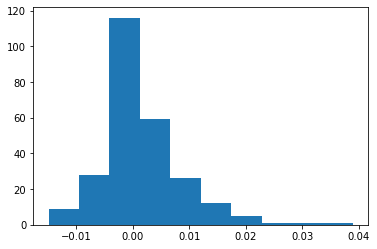

In [50]:
from sklearn import *


target = "SalesPrice"

y = np.log(df[target]) # label

X = df.drop(columns=target) # features


# Derives feature
#X["high_bmi"] = X.bmi>33
#X = pd.get_dummies(X, drop_first=True)
#X["age_band"] = np.where(X.age<40, "b1", np.where(X.age > 70 , "b3", "b2"))

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 986)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.SGDRegressor(alpha=0.8, l1_ratio=0.15, max_iter=10000, random_state=1))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)

print("rmse train", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("rmse test", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("r2 train", metrics.r2_score(y_train, y_train_pred))
print("r2 test", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
est.intercept_, est.coef_
plt.hist(est.coef_);

In [68]:
target = "SalesPrice"
y = np.log(df[target]) # label
X = df.drop(columns=target) # features
X = pd.get_dummies(X, drop_first=True)

pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=10000, random_state=1))
])
scores = model_selection.cross_val_score(pipe, X, y, cv=5)
scores, np.mean(scores), np.std(scores)

(array([0.86755525, 0.86796599, 0.86309903, 0.90278325, 0.76819355]),
 0.8539194144418761,
 0.04517545000546821)

In [69]:
np.linspace(0.001, 1, 20)

array([0.001     , 0.05357895, 0.10615789, 0.15873684, 0.21131579,
       0.26389474, 0.31647368, 0.36905263, 0.42163158, 0.47421053,
       0.52678947, 0.57936842, 0.63194737, 0.68452632, 0.73710526,
       0.78968421, 0.84226316, 0.89484211, 0.94742105, 1.        ])

In [70]:
np.random.random(20)

array([0.23132143, 0.88469585, 0.41587491, 0.69446991, 0.97363145,
       0.90398835, 0.37689715, 0.94042096, 0.6978303 , 0.53169354,
       0.91286784, 0.20588736, 0.03116588, 0.32574948, 0.19492063,
       0.24389796, 0.44702502, 0.57338713, 0.18509053, 0.90283924])

In [73]:
target = "SalesPrice"
y = np.log(df[target]) # label
X = df.drop(columns=target) # features
X = pd.get_dummies(X, drop_first=True)

pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=10000, random_state=1))
])

param_grid = {
    "est__alpha": np.linspace(0.001, 1, 20)
}
gsearch = model_selection.GridSearchCV(pipe, param_grid, scoring = "r2"
                             , cv=5, verbose = True, n_jobs=-1 )

gsearch.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.9s finished


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(degree=1,
                                                           include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('est',
                                        ElasticNet(alpha=0.01, l1_ratio=0.1,
                                                   max_iter=10000,
                                                   random_state=1))]),
             n_jobs=-1,
             param_grid={'est__alpha': array([0.001     , 0.05357895, 0.10615789, 0.15873684, 0.21131579,
       0.26389474, 0.31647368, 0.36905263, 0.42163158, 0.47421053,
       0.52678947, 0.57936842, 0.63194737, 0.68452632, 0.73710526,
       0.78968421, 0.84226316, 0.89484211, 0.94742105, 1.        ])},
             scoring='r2', verbose=True)

In [74]:
gsearch.best_estimator_

Pipeline(steps=[('poly', PolynomialFeatures(degree=1, include_bias=False)),
                ('scaler', StandardScaler()),
                ('est',
                 ElasticNet(alpha=0.05357894736842105, l1_ratio=0.1,
                            max_iter=10000, random_state=1))])

In [75]:
gsearch.best_params_

{'est__alpha': 0.05357894736842105}

In [76]:
gsearch.best_score_

0.8660581107881592

In [77]:
import pickle

In [78]:
with open("/tmp/model.pickle", "wb") as f:
    pickle.dump(gsearch, f)

In [80]:
!ls -hl /tmp/model.pickle

-rw-r--r--  1 abasar  wheel    13K Jul 21 12:32 /tmp/model.pickle


In [81]:
with open("/tmp/model.pickle", "rb") as f:
    model = pickle.load(f)

In [83]:
model.score(X, y)

0.9063500288576988